In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Tell Jupyter to show charts inside the notebook
%matplotlib inline

In [31]:
# Make charts loook clean ans modern
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [32]:
print("All the libraries imported successfully!")

All the libraries imported successfully!


In [33]:
# Reads the csv file and stores it as a "DataFrame"
df = pd.read_csv(r"C:\Users\Shruti Sharma\OneDrive\Documents\Customer_churn_prediction\BankChurners.csv")

# df.shape gives (rows,columns)
print(f"Dataset shape: {df.shape}")

# Show the first 5 rows
df.head()

Dataset shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [34]:
# See all comlumn names
print("📋 Column names:")
print(df.columns.tolist())

print("\n")

📋 Column names:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']




In [35]:
# See the data types of each column
print("📊 Data types:")
print(df.dtypes)
print("\n")

📊 Data types:
CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                        

In [36]:
# See statistics for every number column
# count, mean, min, max, etc.
print("📈 Basic statistics")
print(df.describe())

📈 Basic statistics
          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  1.012700e+04  10127.000000     10127.000000    10127.000000   
mean   7.391776e+08     46.325960         2.346203       35.928409   
std    3.690378e+07      8.016814         1.298908        7.986416   
min    7.080821e+08     26.000000         0.000000       13.000000   
25%    7.130368e+08     41.000000         1.000000       31.000000   
50%    7.179264e+08     46.000000         2.000000       36.000000   
75%    7.731435e+08     52.000000         3.000000       40.000000   
max    8.283431e+08     73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count              10127.000000            10127.000000   
mean                   3.812580                2.341167   
std                    1.554408                1.010622   
min                    1.000000                0.000000   
25%                    3.000000                2.000000

In [37]:
columns_to_drop = ["CLIENTNUM", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"]

df = df.drop(columns = columns_to_drop)

print(f"Columns after dropping: {df.shape[1]}")

Columns after dropping: 20


In [38]:
# ─── ENCODE TARGET VARIABLE ────────────────────────────────
# Our target column is "Attrition_Flag"
# Right now it contains text: "Attrited Customer" or "Existing Customer"
# ML models only understand numbers, not text

# Let's see what values it currently has
print("Current values:")
print(df["Attrition_Flag"].value_counts())   

Current values:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [39]:
# Convert: Attrited Customer → 1 (churned)
#          Existing Customer → 0 (stayed)
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Attrited Customer": 1,
    "Existing Customer": 0 })

print("\nAfter conversion:")
print(df["Attrition_Flag"].value_counts())
print(f"\nChurn rate: {df['Attrition_Flag'].mean()*100:.1f}%")


After conversion:
Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

Churn rate: 16.1%


In [40]:
# ─── MISSING VALUES ────────────────────────────────────────
# Missing values = empty cells in your data
# ML models crash or give wrong results if you feed them empty cells

missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0]) #Only show columns that have missing values

# If output is empty, congratulations — no missing values!
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


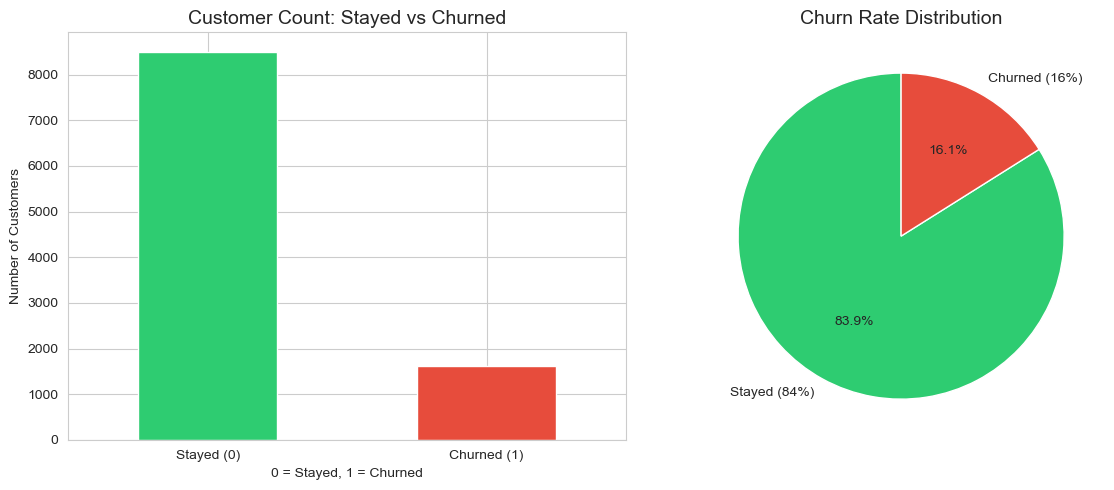

Chart saved!


In [42]:
# ─── CHART 1: Churn Distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Left chart: simple count bar
df["Attrition_Flag"].value_counts().plot(
    kind = 'bar',
    ax = axes[0],
    color = ['#2ecc71', '#e74c3c'],
    edgecolor = 'white')

axes[0].set_title("Customer Count: Stayed vs Churned", fontsize = 14)
axes[0].set_xlabel("0 = Stayed, 1 = Churned")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticklabels(["Stayed (0)", "Churned (1)"], rotation=0)

# Right chart: percentage pie chart
sizes = df["Attrition_Flag"].value_counts()
axes[1].pie(
    sizes,
    labels = ["Stayed (84%)", "Churned (16%)"],
    colors = ["#2ecc71", "#e74c3c"],
    autopct = "%1.1f%%",
    startangle = 90
)
axes[1].set_title("Churn Rate Distribution", fontsize = 14)

plt.tight_layout()
plt.savefig("churn_distribution.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("Chart saved!")

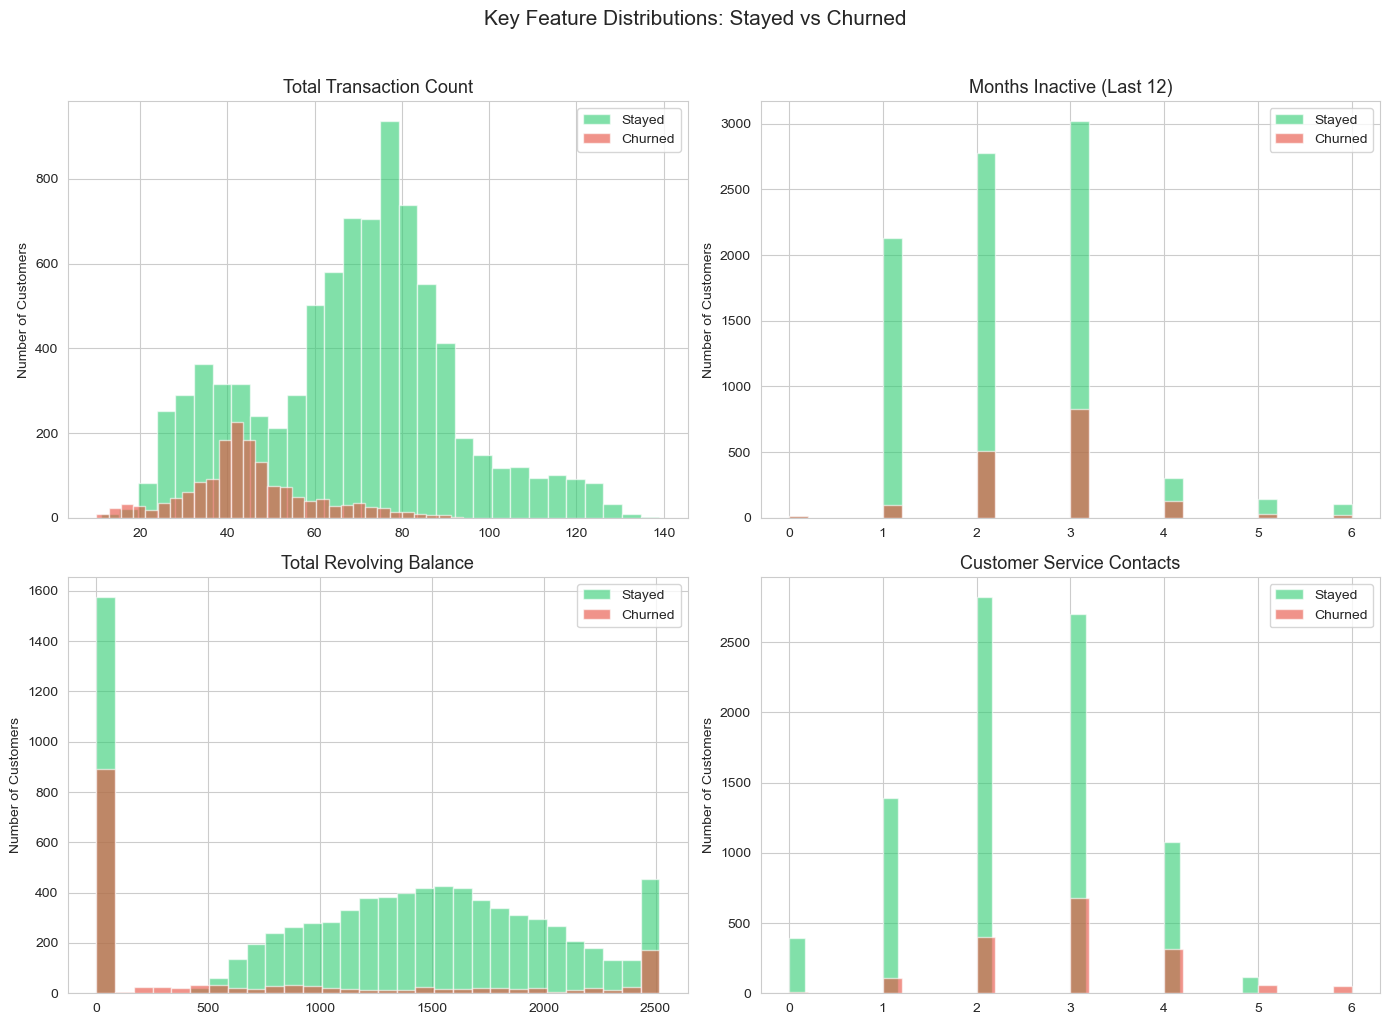

In [47]:
# ─── CHART 2: Key Features vs Churn ────────────────────────
# These 4 features are the strongest churn predictors
# Let's visually confirm WHY

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

features = [
    ("Total_Trans_Ct",         "Total Transaction Count"),
    ("Months_Inactive_12_mon", "Months Inactive (Last 12)"),
    ("Total_Revolving_Bal",    "Total Revolving Balance"),
    ("Contacts_Count_12_mon",   "Customer Service Contacts")
    ]

for ax, (col, title) in zip(axes.flat, features):
    # Plot distribution for churned vs not churned
    df[df["Attrition_Flag"] == 0][col].hist(
        ax=ax, alpha = 0.6, color = "#2ecc71", label = "Stayed", bins = 30)

    df[df["Attrition_Flag"] == 1][col].hist(
        ax=ax, alpha = 0.6, color = "#e74c3c", label = "Churned", bins = 30)
    ax.set_title(title, fontsize = 13)
    ax.legend()
    ax.set_ylabel("Number of Customers")

plt.suptitle("Key Feature Distributions: Stayed vs Churned",
             fontsize = 15, y = 1.02)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
# ─── ENCODE CATEGORICAL COLUMNS ────────────────────────────
# Some columns contain text categories like "Male"/"Female"
# or "Graduate"/"High School" — we must convert to numbers

# First, find all text columns
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Text columns that need encoding:")
print(cat_cols)

# Use Label Encoding — converts each category to a number
# Male → 0, Female → 1  (or vice versa, order doesn't matter)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"  ✅ Encoded: {col}")

print("\nAll text columns converted to numbers!")
df.head()

Text columns that need encoding:
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
  ✅ Encoded: Gender
  ✅ Encoded: Education_Level
  ✅ Encoded: Marital_Status
  ✅ Encoded: Income_Category
  ✅ Encoded: Card_Category

All text columns converted to numbers!


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [50]:
# ─── FINAL CHECK ───────────────────────────────────────────
print("=" * 50)
print("PHASE 2 COMPLETE — DATA SUMMARY")
print("=" * 50)
print(f"Total rows:     {df.shape[0]}")
print(f"Total columns:  {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Churn rate:     {df['Attrition_Flag'].mean()*100:.1f}%")
print(f"Data types OK:  {(df.dtypes == 'object').sum() == 0}")
print("=" * 50)

# Save cleaned data so we don't redo this work
df.to_csv("data/cleaned_data.csv", index=False)
print("\n Cleaned data saved to data/cleaned_data.csv")

PHASE 2 COMPLETE — DATA SUMMARY
Total rows:     10127
Total columns:  20
Missing values: 0
Churn rate:     16.1%
Data types OK:  True

 Cleaned data saved to data/cleaned_data.csv
